In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define dataset without normalization
transform = transforms.Compose([
    transforms.Resize((224 , 224)),
    transforms.ToTensor()  # Convert images to tensors
])

dataset = datasets.ImageFolder(root=  "C:/Users/ragha/Downloads/train", transform=transform)
loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

# Function to calculate mean and std
def calculate_mean_std(loader):
    mean = 0.0
    std = 0.0
    total_samples = 0

    for images, _ in loader:
        
        # Batch dimensions: (batch_size, channels, height, width)
        batch_samples = images.size(0)  # Number of images in the batch
       
        images = images.view(batch_samples, images.size(1), -1)  # Flatten HxW
        mean += images.mean(2).sum(0)  # Sum mean of all channels
        std  += images.std(2).sum(0)  # Sum std of all channels
        total_samples += batch_samples
        

    mean /= total_samples
    std /= total_samples
    return mean, std

# Compute mean and std
mean, std = calculate_mean_std(loader)
print("Mean:", mean)
print("Std:", std)


Mean: tensor([0.4823, 0.4823, 0.4823])
Std: tensor([0.2216, 0.2216, 0.2216])


In [3]:
import torch
from torchvision import datasets , models , transforms
from torchvision.models import resnet18 , ResNet18_Weights
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader , TensorDataset
import torch.optim as optim


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(200),
    transforms.ToTensor(),
    transforms.Normalize((0.4823, 0.4823, 0.4823), (0.2216, 0.2216, 0.2216))
])


test_transform = transforms.Compose([
       transforms.Grayscale(num_output_channels = 3),
       transforms.Resize((224 ,224)),
       transforms.ToTensor(),
       transforms.Normalize((0.4823, 0.4823, 0.4823) , (0.2216, 0.2216, 0.2216))
])
train_dataset = datasets.ImageFolder(root = "C:/Users/ragha/Downloads/train" , transform = train_transform)
test_dataset  = datasets.ImageFolder(root = "C:/Users/ragha/Downloads/test" ,  transform = test_transform)

train_loader = DataLoader(train_dataset , batch_size = 64 , shuffle = True)
test_loader  = DataLoader(test_dataset , batch_size = 64)

from torchvision.models import resnet50 , ResNet50_Weights


model = resnet50(pretrained =True)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
       nn.Linear(num_ftrs , 512),
       nn.ReLU(),
       nn.Dropout(p = 0.5),
       nn.Linear(512 , 256),
       nn.ReLU(),
       nn.Dropout(p= 0.5),
       nn.Linear(256,128),
       nn.ReLU(),
       nn.Dropout(p = 0.5),
       nn.Linear(128 , 2)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

epochs = 5
for epoch in range(epochs):
    correct = 0
    total_loss = 0
    total = 0
    model.train()
    for images , labels in train_loader:
        images , labels = images.to(device) , labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs , labels)
        loss.backward()
        optimizer.step()
        total += labels.size(0)
        total_loss += loss.item()
        _ , predicted = torch.max(outputs , 1)
        correct += (predicted == labels).sum().item()

    accuracy = 100*correct/total    
    print(f"Epoch : {epoch+1}/{epochs} , Total Loss : {total_loss} , Accuracy : {accuracy}")    
    


d:\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch : 1/5 , Total Loss : 18.39236767962575 , Accuracy : 90.06901840490798
Epoch : 2/5 , Total Loss : 11.007505308836699 , Accuracy : 95.20705521472392
Epoch : 3/5 , Total Loss : 9.590107951313257 , Accuracy : 96.05061349693251
Epoch : 4/5 , Total Loss : 7.9361235443502665 , Accuracy : 96.51073619631902
Epoch : 5/5 , Total Loss : 9.008377354592085 , Accuracy : 96.0122699386503


In [4]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images , labels in test_loader:
        images , labels = images.to(device) , labels.to(device)
        outputs = model(images)
        _ ,predicted = torch.max(outputs , 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

accuracy1 = (correct/total)*100
print(accuracy1)

88.11074918566774


In [5]:
torch.save(model.state_dict() , "Pneumonia vs normal.pth")

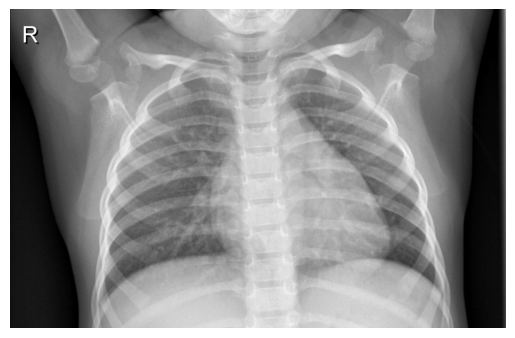

C:\Users\ragha\AppData\Local\Temp\ipykernel_364\1800182485.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('Pneumonia vs normal.pth'))


PNEUMONIA


In [8]:
from PIL import Image , ImageOps
import matplotlib.pyplot as plt

transform = transforms.Compose([
      transforms.Resize((224 , 224)),
      transforms.ToTensor()
])


image = Image.open("C:/Users/ragha/Downloads/NORMAL-1771524-0001.jpeg").convert("RGB")
plt.axis('off')
plt.imshow(image)
plt.show()

model.load_state_dict(torch.load('Pneumonia vs normal.pth'))
model.eval()

classes = ['NORMAL' , "PNEUMONIA"]

image_tensor = transform(image).unsqueeze(0).to(device)
with torch.no_grad():
    outputs = model(image_tensor)
    _ , predicted = torch.max(outputs, 1)

predicted_class = classes[predicted.item()]
print(predicted_class)